## Setup

In [1]:
import numpy as np
    
item_count = 16
param_path = "D:/data/base_cmr_parameters.json"

# mfc associates an item and an evolved contextual state
encoded_item = np.eye(item_count)[0]
new_context = np.array([
    0.5978168,  0.80163276, 0., 0., 0., 0.,
    0., 0., 0., 0., 0., 0.,
    0., 0., 0., 0., 0., 0.])

## Numba Implementation

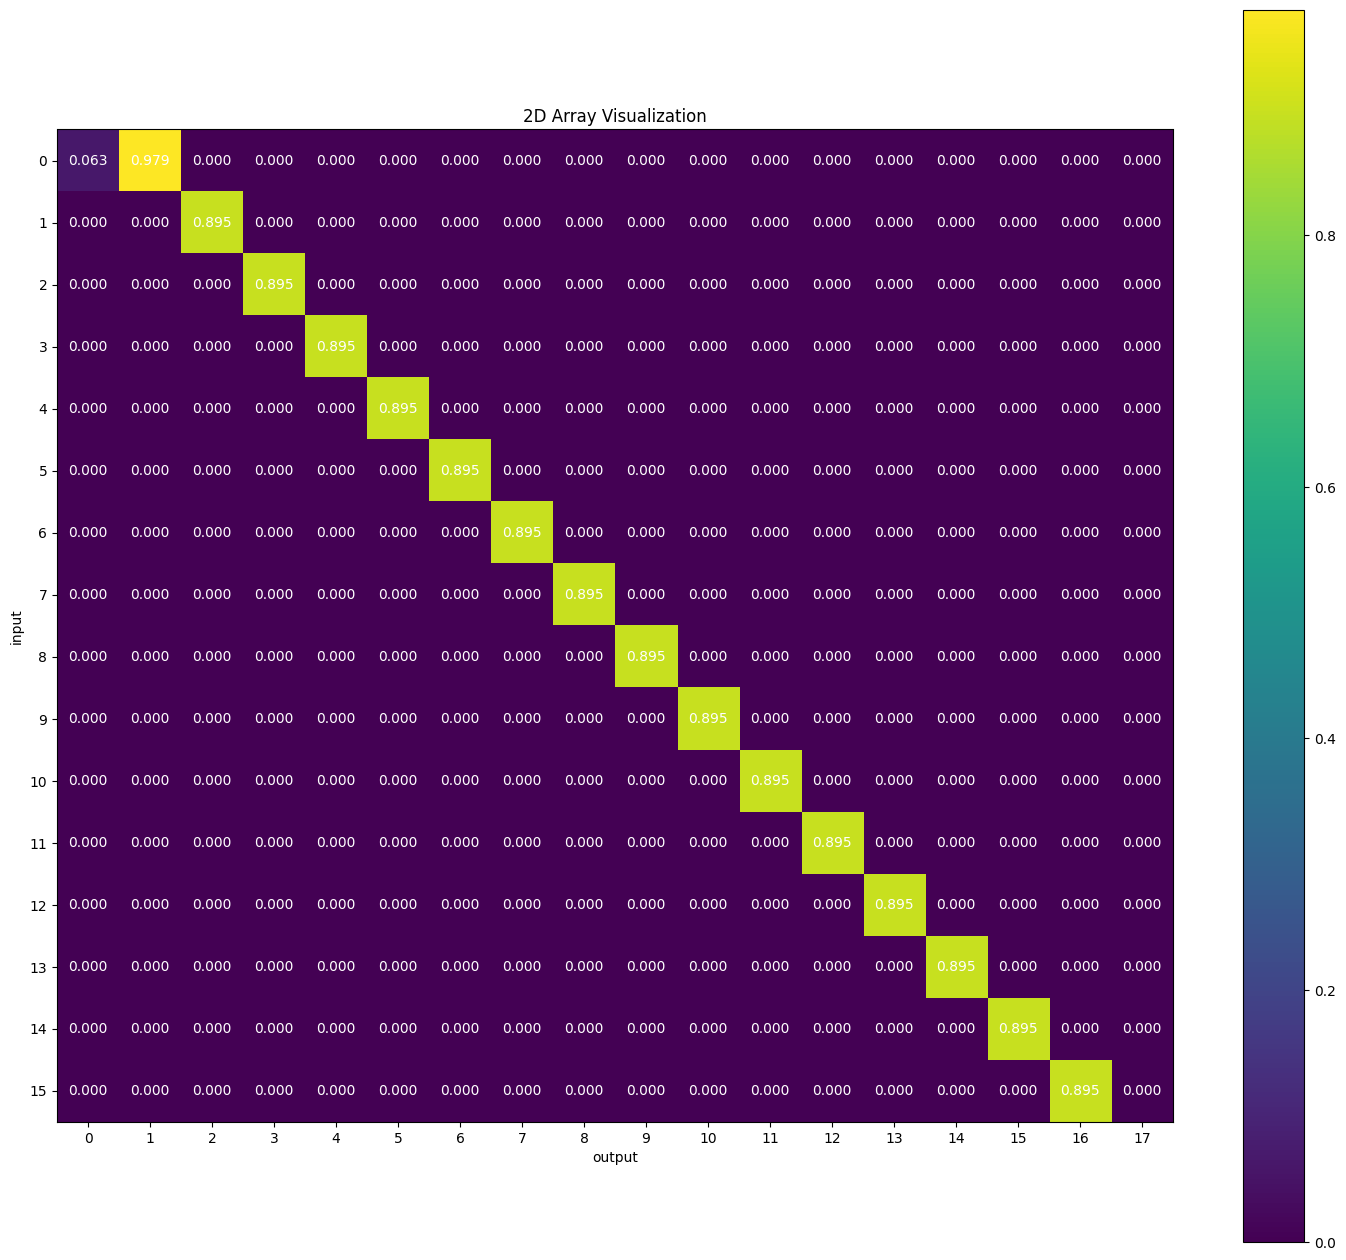

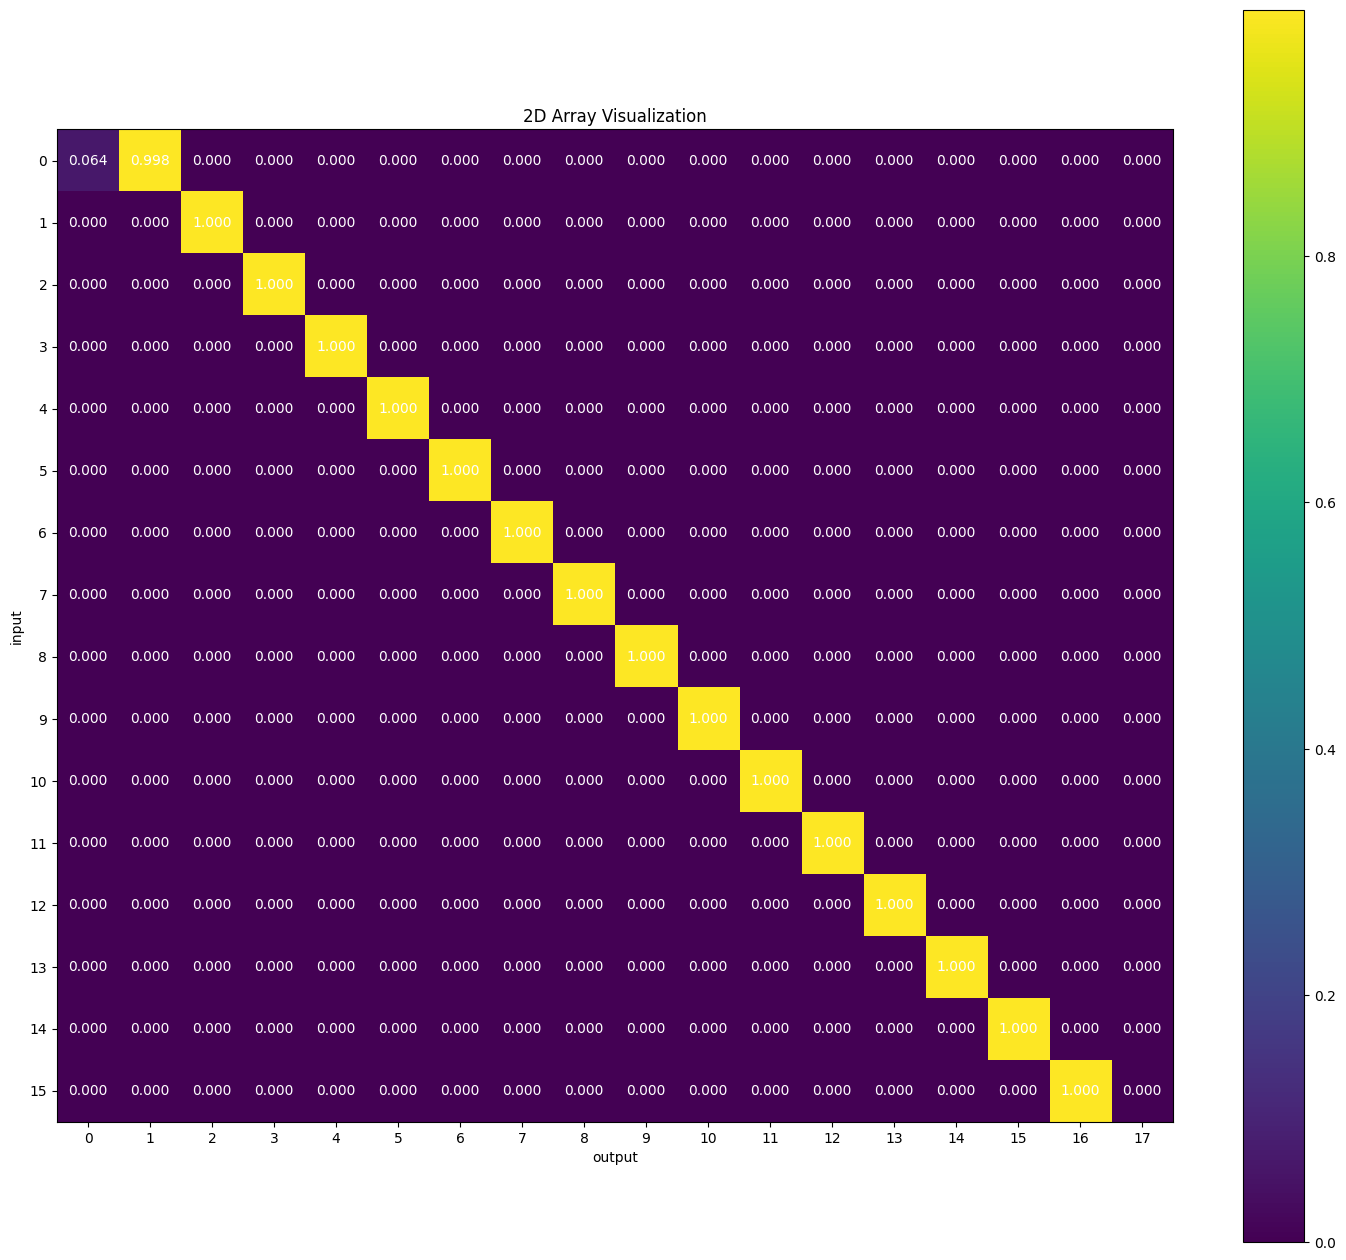

In [2]:
from compmempy.parameters import Parameters
from compmempy.simulation import orthonormal_activation_matrix, visualize_2d_array
from compmempy.models.memory import LinearAssociativeMfc

# parametrization
parameters = Parameters(param_path).fixed
items = np.eye(item_count)

# simulation
memory = LinearAssociativeMfc(items, item_count, parameters)
memory.associate(encoded_item, new_context)

visualize_2d_array(memory.memory)
visualize_2d_array(orthonormal_activation_matrix(memory))

## Jax Implementation

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


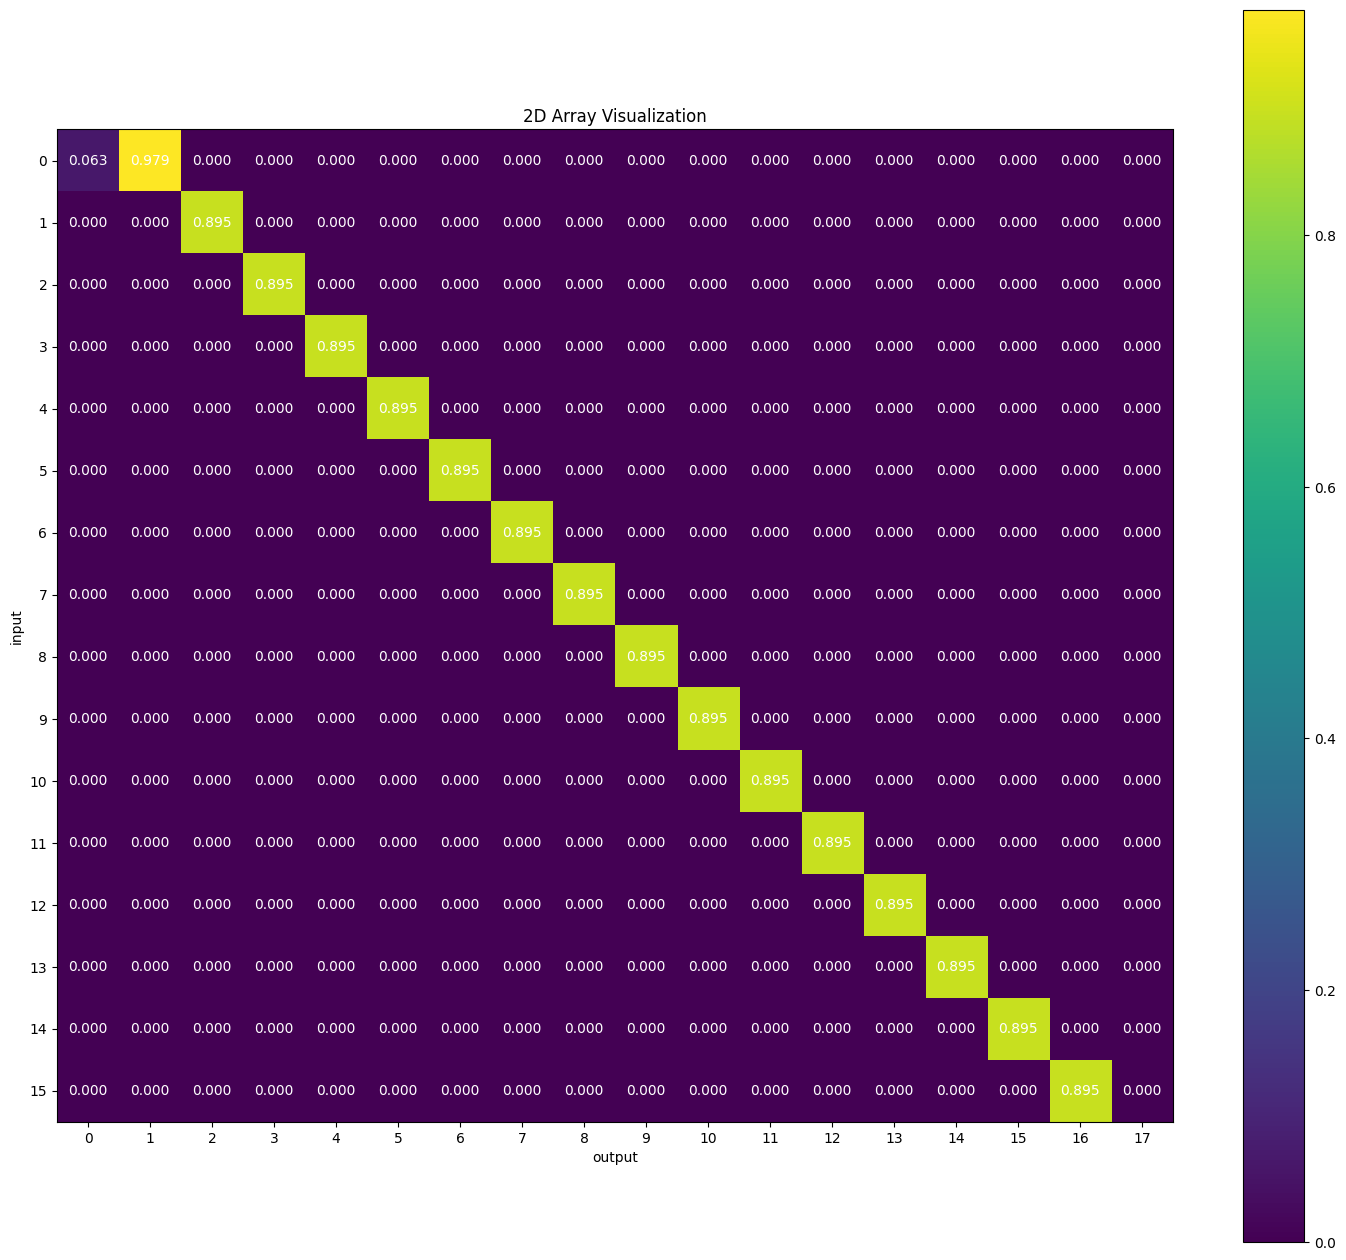

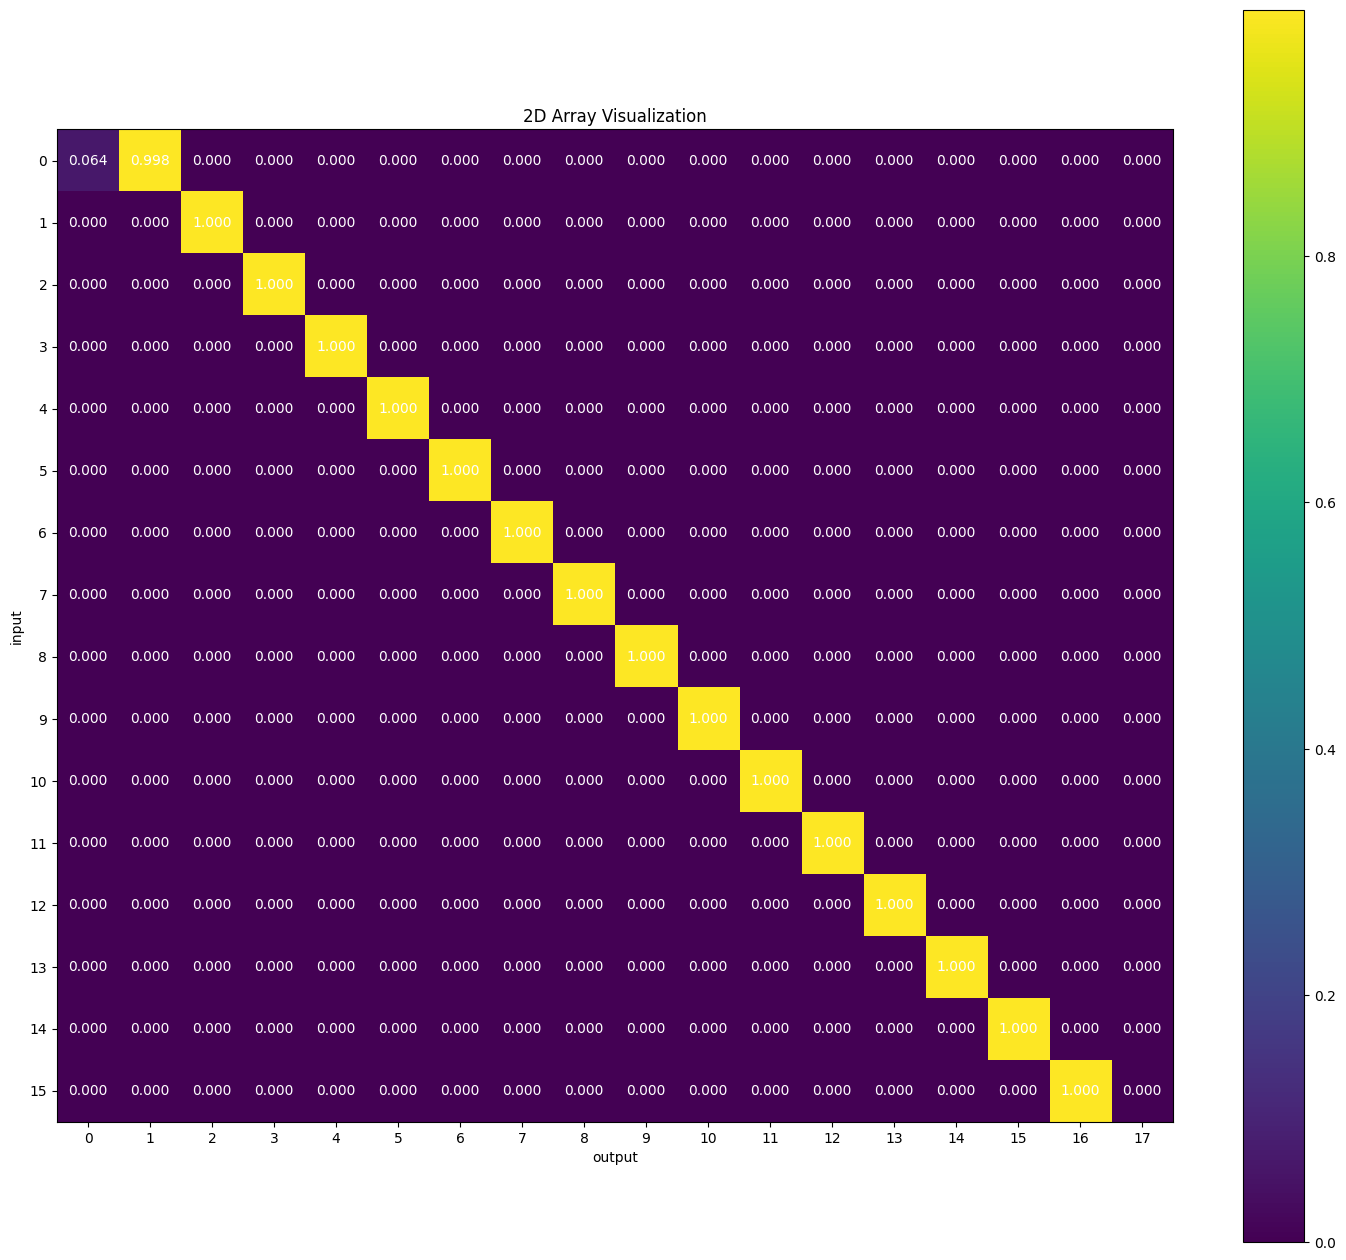

In [3]:
from jaxcmr.memory import LinearAssociativeMfc, associate, probe
from jax import lax

memory = LinearAssociativeMfc.create(item_count, parameters['learning_rate'])
memory = associate(memory, parameters['learning_rate'], encoded_item, new_context)

orthonormal_activation_matrix = lax.map(
    lambda _probe: probe(memory, _probe), 
    np.eye(memory.state.shape[0])
    )

visualize_2d_array(memory.state)
visualize_2d_array(orthonormal_activation_matrix)